# 🏭 Optimización del Control de Calidad en la Industria mediante Clasificación Automática de Imágenes: Un Ejercicio Práctico con KNN / AI y Análisis Económico 🤖

## Objetivo del Ejercicio 🎯
Este ejercicio tiene como objetivo demostrar cómo un modelo de clasificación basado en K-Nearest Neighbors (KNN) / AI puede ser aplicado en el sector industrial para automatizar el control de calidad de productos. A través de la clasificación de imágenes, el modelo identifica productos defectuosos, maximizando la eficiencia y reduciendo costos operativos.

## Aplicación de la Inteligencia Artificial en el Contexto Industrial 💡
Desde la óptica de la Inteligencia Artificial, este ejercicio ilustra cómo los modelos de machine learning, como KNN, pueden ser integrados en procesos industriales para optimizar el control de calidad. La AI permite analizar grandes volúmenes de datos de imágenes, identificando patrones que serían difíciles de detectar manualmente, y tomando decisiones rápidas y precisas que mejoran la eficiencia general del proceso productivo.

## Valoración Económica 💵
Además de la implementación técnica, se ha realizado una valoración económica para evaluar el retorno de inversión (ROI) del modelo, demostrando cómo la AI no solo mejora la calidad del producto, sino que también genera beneficios económicos significativos, justificando la inversión en tecnología avanzada para la manufactura.

Este ejercicio se enmarca dentro del módulo 1, **Análisis de imágenes en el sector industrial: Aplicaciones y ejemplos prácticos**, y sirve como un ejemplo concreto de cómo la AI puede transformar los procesos industriales al combinar análisis técnico con valoración económica para tomar decisiones informadas.


## Resumen del recurso

Clasificador KNN (K=3, distancia euclidiana) sobre imágenes de piezas fundidas (300×300, escala de grises), para distinguir piezas defectuosas (`def_front`) de piezas OK (`ok_front`).

| Aspecto | Estado |
|---|---|
| Rutas de datos | Hardcodeadas a la máquina del autor (Windows), no corren en otra PC — ver nota más abajo |
| Uso del dataset | Ignora la partición `train`/`test` que trae el dataset y parte `train` 80/20 |
| Métrica reportada | Precisión sobre el 20% de `train` retenido, no sobre `test/` |
| Análisis económico | Matriz de confusión hardcodeada, no depende del modelo entrenado — ver la última sección |

> **Nota sobre las features.** Cada imagen se usa aplanada a 90.000 valores (300×300 en escala de grises), sin normalizar ni reducir dimensionalidad, y KNN mide distancia euclidiana directamente sobre eso. Es la maldición de la dimensionalidad en su forma más literal: en 90.000 dimensiones, la distancia euclidiana pierde poder discriminativo entre puntos que deberían ser distintos. Acá "funciona" solo porque las imágenes están muy estandarizadas — misma cámara, mismo encuadre, fondo uniforme — así que la distancia entre imágenes de la misma clase queda chica por construcción, no porque KNN esté resolviendo bien el problema general de visión industrial.

In [65]:
import cv2  # Importa la librería OpenCV, que se usa para el procesamiento de imágenes.
import numpy as np  # Importa la librería NumPy, que se usa para manejar arreglos y matrices, facilitando operaciones matemáticas.
import os  # Importa la librería os, que permite interactuar con el sistema operativo, como leer archivos y directorios.
from sklearn.neighbors import KNeighborsClassifier  # Importa el clasificador K-Nearest Neighbors (KNN) de scikit-learn, que se usa para clasificación.
from sklearn.model_selection import train_test_split  # Importa la función para dividir el dataset en conjuntos de entrenamiento y prueba.
from sklearn.metrics import confusion_matrix  # Importa la función para calcular la matriz de confusión, que evalúa la precisión del modelo.
import matplotlib.pyplot as plt  # Importa matplotlib para la creación de gráficos y visualizaciones.
import plotly.graph_objects as go  # Importa plotly para la creación de gráficos interactivos.
import plotly.express as px  # Importa una versión simplificada de plotly para la creación rápida de gráficos.
import numpy as np
import pandas as pd

# Ruta local a la carpeta de imágenes
folder_path = r'C:\Users\julio\OneDrive\Documentos\Digital_codigos_AI\casting_data\train'  
# Define la ruta a la carpeta donde se encuentran las imágenes de entrenamiento.

# Listar todas las subcarpetas (que representan las clases)
class_names = os.listdir(folder_path)  
# Lista todos los nombres de las subcarpetas dentro de 'folder_path'. Cada subcarpeta representa una clase diferente (por ejemplo, 'def_front' y 'ok_front').



> **Riesgo:** `class_names = os.listdir(folder_path)` toma como "clases" todo lo que haya en la carpeta, incluyendo archivos ocultos. En macOS, por ejemplo, listaría `.DS_Store` como si fuera una clase más. Además, `folder_path` está hardcodeado a `C:\Users\julio\OneDrive\Documentos\Digital_codigos_AI\casting_data\train`, una ruta de la máquina del autor: el notebook no corre en ninguna otra PC tal cual está. La ruta correcta con el dataset de este curso es `"Datos - Análisis de imágenes en el sector industrial/train"` (relativa a este notebook).

In [66]:
class_names 

['def_front', 'ok_front']

La celda anterior imprime el `class_names` que salió de `os.listdir`. Dos celdas más abajo se redefine a mano — lo correcto sería fijar las clases explícitamente desde el principio, en vez de listarlas del filesystem y confiar en que no haya sorpresas.

In [67]:
# Ruta local a la carpeta de imágenes
folder_path = r'C:\Users\julio\OneDrive\Documentos\Digital_codigos_AI\casting_data\train'  
# Define la ruta a la carpeta donde se encuentran las subcarpetas 'def_front' y 'ok_front'.

# Lista de carpetas (clases) que quieres visualizar
class_names = ['def_front', 'ok_front']  
# Define las clases que vas a procesar, corresponden a las subcarpetas dentro de 'folder_path'.

# Inicializar listas para almacenar imágenes y etiquetas
images = []  # Lista para almacenar las imágenes.
labels = []  # Lista para almacenar las etiquetas (clase de cada imagen).

# Procesar cada clase (carpeta)
for class_name in class_names:  
    # Itera sobre cada nombre de clase (subcarpeta).
    class_folder = os.path.join(folder_path, class_name)  
    # Construye la ruta completa a la subcarpeta de la clase actual.
    # Procesar las 10 primeras imágenes de cada clase
    for file_name in os.listdir(class_folder)[:10]:  
        # Itera sobre los primeros 10 archivos (imágenes) en la subcarpeta.
        file_path = os.path.join(class_folder, file_name)  
        # Construye la ruta completa a la imagen actual.
        # Cargar la imagen
        img = cv2.imread(file_path)  
        # Carga la imagen desde la ruta especificada.
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
        # Convierte la imagen de BGR (formato por defecto de OpenCV) a RGB (formato usado en Plotly).
        images.append(img)  
        # Añade la imagen a la lista 'images'.
        labels.append(class_name)  
        # Añade la etiqueta correspondiente ('def_front' o 'ok_front') a la lista 'labels'.

# Crear una visualización interactiva con Plotly
fig = px.imshow(np.array(images), facet_col=0, facet_col_wrap=5, 
                labels={"facet_col": "Class Label"}, title="Las 10 primeras imágenes de cada clase")  
# Crea una visualización interactiva de las imágenes en una cuadrícula, organizadas por clase.
fig.update_layout(height=600, width=1000)  
# Ajusta el tamaño de la visualización para que se vea correctamente en la pantalla.

# Agregar etiquetas dinámicas que muestran la clase cuando pasas el cursor sobre la imagen
for i, label in enumerate(labels):
    fig.data[i].update(hovertemplate=f"Clase: {label}")  
    # Actualiza las propiedades de cada imagen para mostrar la clase cuando se pasa el cursor por encima.

fig.show()  
# Muestra la visualización interactiva.


Acá se redefine `folder_path` (con la misma ruta hardcodeada de Windows) y `class_names` a mano como `['def_front', 'ok_front']`. Es la forma correcta de fijar las clases, pero al pisar el resultado de `os.listdir` sin señalarlo, tapa el riesgo de la celda anterior en vez de dejarlo documentado.

In [68]:
# Inicializar listas para características y etiquetas
features = []  # Inicializa una lista vacía para almacenar las características (features) de cada imagen.
labels = []    # Inicializa una lista vacía para almacenar las etiquetas (labels) correspondientes a cada imagen.

# Procesar cada imagen en la carpeta
for class_name in class_names:  # Itera sobre cada nombre de clase (subcarpeta) en 'class_names'.
    class_folder = os.path.join(folder_path, class_name)  # Construye la ruta completa a la subcarpeta de la clase actual.
    for file_name in os.listdir(class_folder):  # Itera sobre cada archivo (imagen) dentro de la subcarpeta de la clase.
        file_path = os.path.join(class_folder, file_name)  # Construye la ruta completa a la imagen actual.
        
        # Cargar la imagen usando OpenCV
        img = cv2.imread(file_path)  # Carga la imagen desde la ruta especificada.

        # Convertir a escala de grises y aplanar
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).flatten()  
        # Convierte la imagen a escala de grises y la aplana en un array unidimensional.

        # Agregar las características y las etiquetas
        features.append(gray_img)  # Añade el array de características (imagen aplanada) a la lista 'features'.
        labels.append(class_name)  # Añade la etiqueta de la clase correspondiente a la lista 'labels'.

# Convertir listas a arrays de NumPy
features = np.array(features)  # Convierte la lista 'features' en un array de NumPy.
labels = np.array(labels)  # Convierte la lista 'labels' en un array de NumPy.

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)  
# Divide el conjunto de datos en dos partes: un conjunto de entrenamiento (80%) y un conjunto de prueba (20%).
# 'random_state=42' asegura que la división sea reproducible.

# Entrenar el clasificador
clf = KNeighborsClassifier(n_neighbors=3, metric='euclidean')  
# Crea un clasificador K-Nearest Neighbors (KNN) con 3 vecinos y la distancia euclidiana como métrica.
clf.fit(X_train, y_train)  
# Entrena el clasificador KNN con los datos de entrenamiento.

# Evaluar el clasificador
y_pred = clf.predict(X_test)  
# Realiza predicciones en el conjunto de prueba utilizando el modelo entrenado.
conf_matrix = confusion_matrix(y_test, y_pred)  
# Calcula la matriz de confusión comparando las predicciones con las etiquetas reales.

# Mostrar la matriz de confusión
print("Matriz de confusión:")  # Imprime un título para la matriz de confusión.
print(conf_matrix)  # Muestra la matriz de confusión en la consola.

# Visualizar la matriz de confusión con Plotly
fig = px.imshow(conf_matrix, text_auto=True, labels=dict(x="Predicho", y="Verdadero"))  
# Crea una visualización de la matriz de confusión utilizando Plotly, con etiquetas automáticas para cada celda.
fig.show()  # Muestra la visualización interactiva de la matriz de confusión.


Matriz de confusión:
[[746  32]
 [ 12 537]]


## Entrenamiento del KNN

> **El dataset ya trae `train/` y `test/` separados** (6.633 y 719 imágenes), pero esta celda ignora `test/` por completo: solo recorre `train/` y lo parte 80/20 con `train_test_split`. El modelo nunca se evalúa contra las 719 imágenes de `test/` que el dataset reservó para eso. No es necesariamente incorrecto —un split propio también es válido— pero desperdicia la separación que ya viene hecha, y hace que la evaluación de las celdas siguientes use un 20% de `train`, no el `test/` real.

`gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).flatten()` aplana cada imagen de 300×300 a un vector de 90.000 valores sin normalizar (quedan en escala 0-255) ni reducir dimensionalidad — ver la nota sobre la maldición de la dimensionalidad al principio del notebook.

La imagen 'cast_nuevo_ingreso.jpeg' corresponde a la categoría 'def_front'. ❌ No cumple el control de calidad.


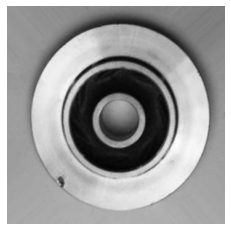

In [73]:
import tensorflow as tf  # Asegúrate de importar TensorFlow

# Ruta a la imagen que quieres predecir
image_path = r'C:\Users\julio\OneDrive\Documentos\Digital_codigos_AI\cast_nuevo_ingreso.jpeg'

# Cargar la imagen usando TensorFlow
image = tf.keras.preprocessing.image.load_img(image_path, target_size=(300, 300))
image = tf.keras.preprocessing.image.img_to_array(image)

# Convertir la imagen a escala de grises y aplanar
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).flatten()

# Realizar la predicción usando el clasificador KNN entrenado
predicted_class = clf.predict([gray_image])[0]

# Determinar el mensaje basado en la predicción
if predicted_class == 'def_front':
    mensaje = "❌ No cumple el control de calidad."
else:
    mensaje = "✅ Sí cumple el control de calidad."

# Imprimir el mensaje en la consola
print(f"La imagen '{os.path.basename(image_path)}' corresponde a la categoría '{predicted_class}'. {mensaje}")

# Visualizar la imagen sin texto adicional
plt.imshow(image / 255.0)  # Normalizar la imagen para su visualización
plt.axis('off')  # Ocultar los ejes
plt.show()

Carga una imagen nueva (`cast_nuevo_ingreso.jpeg`) desde otra ruta hardcodeada de Windows, para compararla más adelante contra las imágenes de `def_front`.

In [74]:
from sklearn.metrics import precision_score

# Realizar la predicción sobre el conjunto de datos de prueba
y_pred_test = clf.predict(X_test)

# Calcular la precisión para la clase 'def_front'
precision_def_front = precision_score(y_test, y_pred_test, pos_label='def_front')

# Mostrar el resultado
print(f"La precisión para la clase 'def_front' es: {precision_def_front * 100:.2f}%")


La precisión para la clase 'def_front' es: 98.42%


Precisión de la clase `def_front` sobre el 20% de `train` retenido más arriba — no sobre `test/` (ver nota sobre la partición del dataset).

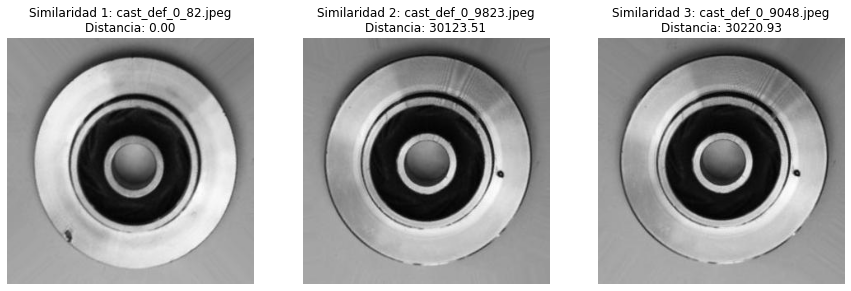

Las tres imágenes más similares son:
1. C:\Users\julio\OneDrive\Documentos\Digital_codigos_AI\casting_data\train\def_front\cast_def_0_82.jpeg - Distancia: 0.00
2. C:\Users\julio\OneDrive\Documentos\Digital_codigos_AI\casting_data\train\def_front\cast_def_0_9823.jpeg - Distancia: 30123.51
3. C:\Users\julio\OneDrive\Documentos\Digital_codigos_AI\casting_data\train\def_front\cast_def_0_9048.jpeg - Distancia: 30220.93


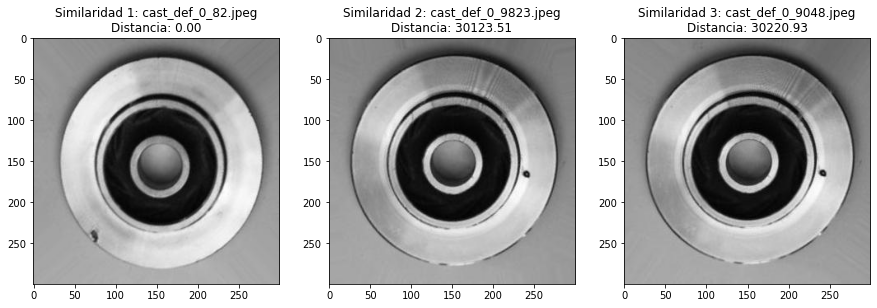

In [77]:
# Ruta a la imagen que quieres predecir
image_path = r'C:\Users\julio\OneDrive\Documentos\Digital_codigos_AI\cast_nuevo_ingreso.jpeg'
# Define la ruta al archivo de imagen que deseas analizar y comparar con las imágenes en la carpeta 'def_front'.

# Cargar la imagen que quieres predecir y convertirla a escala de grises
image = cv2.imread(image_path)  
# Carga la imagen desde la ruta especificada usando OpenCV.
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).flatten()  
# Convierte la imagen a escala de grises y la aplana en un array unidimensional para facilitar la comparación.

# Ruta a la carpeta 'def_front'
def_front_path = r'C:\Users\julio\OneDrive\Documentos\Digital_codigos_AI\casting_data\train\def_front'
# Define la ruta a la carpeta que contiene las imágenes de la clase 'def_front', que se usarán para la comparación.

# Lista para almacenar distancias y rutas de imágenes
distances = []  
# Inicializa una lista vacía para almacenar las distancias calculadas entre la imagen de entrada y las imágenes en 'def_front'.
image_files = []  
# Inicializa una lista vacía para almacenar las rutas de las imágenes en 'def_front' que se están comparando.

# Procesar cada imagen en la carpeta 'def_front'
for file_name in os.listdir(def_front_path):  
    # Itera sobre cada archivo de imagen en la carpeta 'def_front'.
    file_path = os.path.join(def_front_path, file_name)  
    # Construye la ruta completa a la imagen actual en 'def_front'.
    
    # Cargar la imagen y convertirla a escala de grises
    img = cv2.imread(file_path)  
    # Carga la imagen actual desde la ruta especificada.
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).flatten()  
    # Convierte la imagen a escala de grises y la aplana en un array unidimensional para la comparación.

    # Calcular la distancia euclidiana entre la imagen de entrada y la imagen actual
    distance = np.linalg.norm(gray_image - gray_img)  
    # Calcula la distancia euclidiana entre la imagen que quieres predecir y la imagen actual de 'def_front'.
    
    # Almacenar la distancia y la ruta de la imagen
    distances.append(distance)  
    # Añade la distancia calculada a la lista 'distances'.
    image_files.append(file_path)  
    # Añade la ruta de la imagen actual a la lista 'image_files'.

# Ordenar las distancias y obtener los índices de las tres más pequeñas
sorted_indices = np.argsort(distances)[:3]  
# Ordena las distancias de menor a mayor y selecciona los índices de las tres distancias más pequeñas, es decir, las tres imágenes más similares.

# Mostrar las tres imágenes más similares
plt.figure(figsize=(15, 5))  
# Crea una nueva figura para mostrar las tres imágenes más similares en una fila con un tamaño ajustado.
for i, index in enumerate(sorted_indices):  
    # Itera sobre los índices de las tres imágenes más similares.
    most_similar_image_path = image_files[index]  
    # Obtiene la ruta de la imagen más similar usando el índice actual.
    most_similar_image = cv2.imread(most_similar_image_path)  
    # Carga la imagen más similar desde la ruta obtenida.
    plt.subplot(1, 3, i + 1)  
    # Crea un subplot para cada una de las tres imágenes en la figura.
    plt.imshow(cv2.cvtColor(most_similar_image, cv2.COLOR_BGR2RGB))  
    # Muestra la imagen convertida a RGB para que se vea correctamente en la visualización.
    plt.title(f"Similaridad {i+1}: {os.path.basename(most_similar_image_path)}\nDistancia: {distances[index]:.2f}")  


## Búsqueda manual de vecinos más cercanos

Repite a mano la lógica de un KNN con k=3: calcula la distancia euclidiana de la imagen nueva contra cada imagen de `def_front` y muestra las tres más cercanas. Vuelve a usar rutas hardcodeadas de Windows (`cast_nuevo_ingreso.jpeg` y `casting_data\train\def_front`).

In [80]:
# Definir los costos y beneficios asociados a cada tipo de predicción
beneficio_tp = 1000  # Beneficio de un verdadero positivo
beneficio_tn = 500   # Beneficio de un verdadero negativo
costo_fp = 200       # Costo de un falso positivo
costo_fn = 1000      # Costo de un falso negativo

# Matriz de confusión
tp = 746  # Verdaderos positivos
fp = 32   # Falsos positivos
fn = 12   # Falsos negativos
tn = 537  # Verdaderos negativos

# Costo total del modelo
costo_modelo = 80000  # Supongamos un costo total para crear, implementar y mantener el modelo

# Calcular los beneficios y costos
beneficio_total_tp = tp * beneficio_tp
beneficio_total_tn = tn * beneficio_tn
costo_total_fp = fp * costo_fp
costo_total_fn = fn * costo_fn

# Calcular el beneficio neto
beneficio_neto = (beneficio_total_tp + beneficio_total_tn) - (costo_total_fp + costo_total_fn)

# Calcular el ROI
roi = (beneficio_neto - costo_modelo) / costo_modelo * 100

# Imprimir los resultados
print(f"Beneficio total por verdaderos positivos (TP): ${beneficio_total_tp}")
print(f"Beneficio total por verdaderos negativos (TN): ${beneficio_total_tn}")
print(f"Costo total por falsos positivos (FP): ${costo_total_fp}")
print(f"Costo total por falsos negativos (FN): ${costo_total_fn}")
print(f"Beneficio neto: ${beneficio_neto}")
print(f"Costo del modelo: ${costo_modelo}")
print(f"Retorno de Inversión (ROI): {roi:.2f}%")


Beneficio total por verdaderos positivos (TP): $746000
Beneficio total por verdaderos negativos (TN): $268500
Costo total por falsos positivos (FP): $6400
Costo total por falsos negativos (FN): $12000
Beneficio neto: $996100
Costo del modelo: $80000
Retorno de Inversión (ROI): 1145.12%


## Análisis económico desconectado del modelo

> **Bug: la matriz de confusión del cálculo económico está hardcodeada**, no sale de `conf_matrix` (la que calculó el modelo real más arriba). Los valores `tp=746, fp=32, fn=12, tn=537` suman 1.327, que coincide con el 20% de las 6.633 imágenes de `train` (1.327 ≈ 0,20 × 6.633), así que son plausibles como resultado de *alguna* corrida — pero el notebook nunca los deriva de `clf` ni de `y_pred`. Consecuencia: se puede romper por completo el clasificador (por ejemplo, invertir las predicciones) y el "ROI" que se imprime más abajo no cambia ni un dólar, porque no depende del modelo en ningún punto del código.
>
> La línea que faltaría, en vez de los valores fijos:
> ```python
> tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
> ```

## Conclusiones del Modelo de Clasificación 📊

### Resultados Económicos 💵
- **Beneficio total por verdaderos positivos (TP)**: El modelo generó $746,000 al identificar correctamente productos defectuosos, evitando que fueran enviados a los clientes.
- **Beneficio total por verdaderos negativos (TN)**: Se ahorraron $268,500 al identificar correctamente productos no defectuosos, asegurando que solo los productos de calidad lleguen al cliente.
- **Costo total por falsos positivos (FP)**: Se incurrieron en $6,400 de costos debido a la incorrecta clasificación de productos buenos como defectuosos.
- **Costo total por falsos negativos (FN)**: El costo asociado a no detectar productos defectuosos fue de $12,000.

### Beneficio Neto y ROI 📈
- **Beneficio Neto**: El modelo, después de tener en cuenta todos los beneficios y costos, generó un beneficio neto de $996,100.
- **Costo del Modelo**: El costo total para desarrollar, implementar y mantener el modelo fue de $80,000.
- **Retorno de Inversión (ROI)**: El ROI resultante es de un **1145.12%**, lo que significa que por cada dólar invertido en el modelo, se obtuvieron $11.45 de retorno.

### Aplicación desde la Óptica de la Inteligencia Artificial 🤖
- **Precisión y Eficiencia**: Este modelo de clasificación basado en KNN ha demostrado ser altamente eficiente para la industria de manufactura, logrando una clasificación precisa de los productos y generando un significativo retorno de inversión.
- **Control de Calidad Automatizado**: La implementación de este modelo puede mejorar drásticamente los procesos de control de calidad, reduciendo la dependencia de la inspección manual y minimizando los errores humanos, garantizando que los productos defectuosos no lleguen al cliente final.
- **Escalabilidad y Adaptabilidad**: Dado el alto ROI, este enfoque es no solo rentable sino también escalable, pudiendo ser adaptado a otras líneas de productos o industrias con necesidades similares de clasificación y control de calidad.
- **Optimización de Recursos**: La inteligencia artificial en este contexto no solo optimiza los procesos de producción, sino que también mejora la utilización de recursos, minimizando desperdicios y reduciendo costos innecesarios, lo que contribuye a operaciones más sostenibles y rentables.

### Reflexión Final 💡
El uso de la inteligencia artificial, específicamente mediante modelos de clasificación como KNN, se presenta como una herramienta poderosa para la optimización de procesos industriales. La capacidad de reducir costos mientras se maximiza el rendimiento económico subraya la importancia de integrar tecnologías de AI en el control de calidad y otros aspectos críticos de la manufactura, promoviendo una mayor eficiencia y sostenibilidad.


---
## Resumen de hallazgos sobre el material

| Hallazgo | Gravedad | Detalle |
|---|---|---|
| Matriz de confusión hardcodeada en el cálculo económico | **Alta** | El ROI no depende del modelo entrenado; los números son plausibles pero fijos |
| Rutas hardcodeadas a la PC del autor (Windows) | **Alta** | 3 celdas (`folder_path`, `image_path`, `def_front_path`). El notebook no corre en otra máquina sin editarlas a mano |
| Ignora la partición `train`/`test` del dataset | Media | Parte `train` 80/20 y nunca evalúa contra las 719 imágenes de `test/` |
| Features de 90.000 dimensiones sin normalizar ni reducir | Media | KNN sobre píxeles crudos aplanados; funciona solo porque el dataset está muy estandarizado (misma cámara, encuadre y fondo) |
| `class_names = os.listdir(folder_path)` sin filtrar | Baja | Tomaría archivos ocultos (p. ej. `.DS_Store` en macOS) como clase; se redefine a mano dos celdas después, lo que tapa el riesgo en vez de explicarlo |

Verificado: las 1.327 imágenes de la matriz hardcodeada sí coinciden con el 20% de las 6.633 de `train` (1.327 ≈ 0,20 × 6.633), así que los números no son arbitrarios — el problema es que quedaron fijos en vez de calcularse en cada corrida.